# Pittsburgh Bike Routes & Bike Share — Exploratory Analysis

Data sources (all via the [WPRDC](https://data.wprdc.org) open data portal, see `src/fetch_data.py`):
- **POGOH trip data** — every bike-share trip (station-to-station, duration, rider type), monthly.
- **POGOH station locations** — lat/lon + dock count for each station.
- **BikePGH bike lanes** — GIS line data for on-street bike lanes.
- **On-road bicycle pavement markings** — mile-by-mile inventory of bike lanes/sharrows added over time (1980–2016).

Run `python src/fetch_data.py` first to populate `data/raw/`.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from load_data import load_trips, load_stations, load_bike_lanes, load_pavement_markings

trips = load_trips()
stations = load_stations()
lanes = load_bike_lanes()
markings = load_pavement_markings()

print(f"{len(trips):,} trips | {trips.start_date.min().date()} to {trips.start_date.max().date()}")
print(f"{len(stations)} stations | {len(lanes)} bike-lane segments")

1,703,174 trips | 2022-05-01 to 2026-08-31
60 stations | 36 bike-lane segments


## 1. Ridership over time

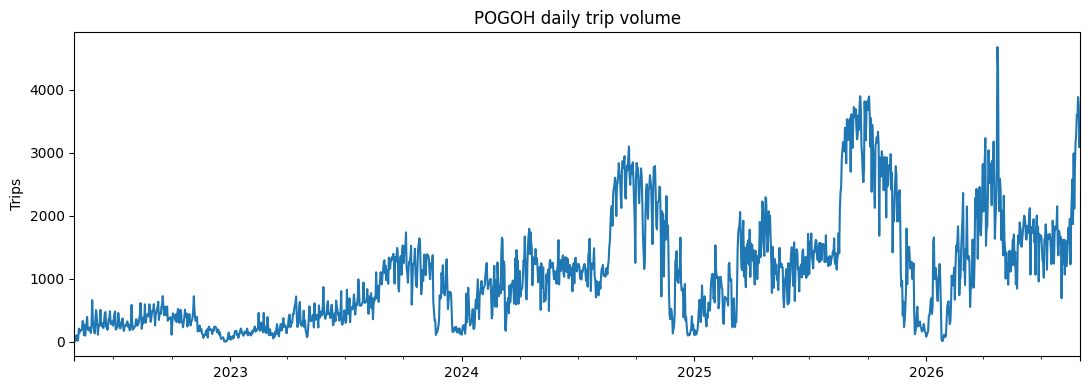

In [2]:
daily = trips.set_index('start_date').resample('D').size()

fig, ax = plt.subplots(figsize=(11, 4))
daily.plot(ax=ax, color='#1f77b4')
ax.set_title('POGOH daily trip volume')
ax.set_ylabel('Trips')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../docs/daily_ridership.png', dpi=150)
plt.show()

## 2. Rider type & trip duration

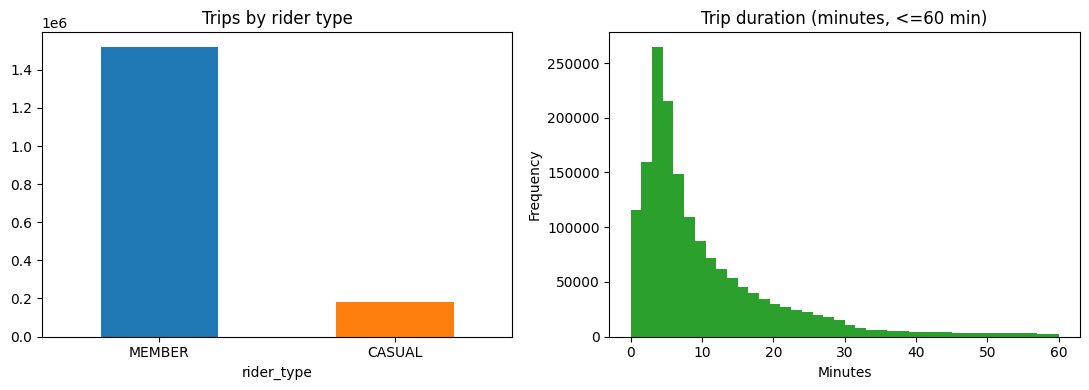

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

trips['rider_type'].value_counts().plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Trips by rider type')
axes[0].tick_params(axis='x', rotation=0)

trips[trips['duration_min'].between(0, 60)]['duration_min'].plot(
    kind='hist', bins=40, ax=axes[1], color='#2ca02c')
axes[1].set_title('Trip duration (minutes, <=60 min)')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.savefig('../docs/rider_type_duration.png', dpi=150)
plt.show()

## 3. Busiest stations

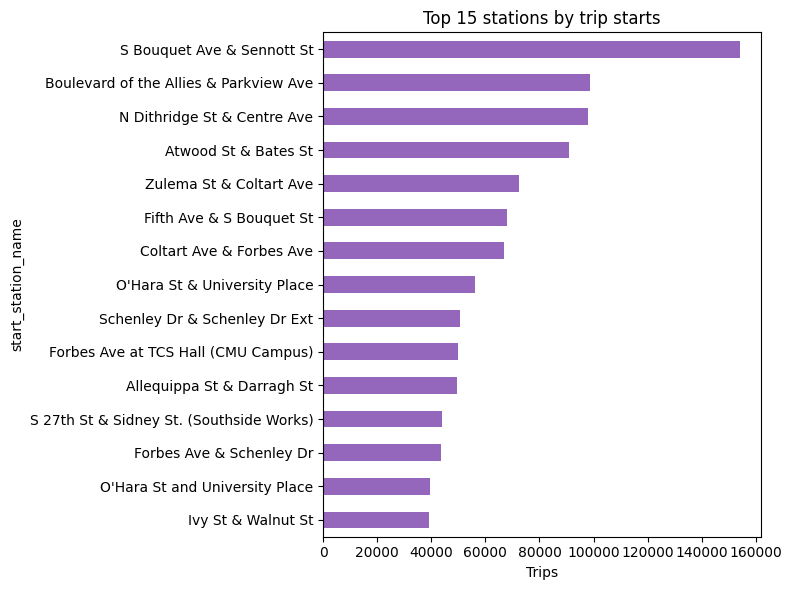

In [4]:
top_start = trips['start_station_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_start.sort_values().plot(kind='barh', ax=ax, color='#9467bd')
ax.set_title('Top 15 stations by trip starts')
ax.set_xlabel('Trips')
plt.tight_layout()
plt.savefig('../docs/top_stations.png', dpi=150)
plt.show()

## 4. Map: stations + bike lane network\n\nInteractive Folium map — station locations sized by dock count, overlaid on the on-street bike lane network.

In [5]:
import folium

m = folium.Map(location=[40.4406, -79.9959], zoom_start=13,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri -- Source: Esri, DeLorme, NAVTEQ')

for _, row in lanes.iterrows():
    coords = [(lat, lon) for lon, lat in row.geometry.coords] if row.geometry.geom_type == 'LineString' else []
    if coords:
        folium.PolyLine(coords, color='#2ca02c', weight=3, opacity=0.7).add_to(m)

for _, s in stations.iterrows():
    folium.CircleMarker(
        location=[s['latitude'], s['longitude']],
        radius=3 + s['total_docks'] / 5,
        color='#1f77b4', fill=True, fill_opacity=0.8,
        popup=f"{s['name']} ({s['total_docks']} docks)",
    ).add_to(m)

m.save('../docs/stations_and_lanes_map.html')
m

/Users/travisfeng/Documents/GitHub/pittsburgh-bike-analysis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 5. Growth of bike infrastructure over time

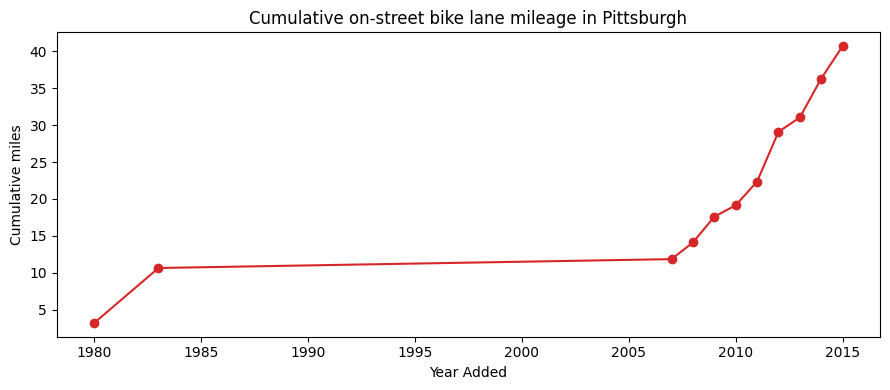

In [6]:
by_year = markings.groupby('Year Added')['Bike Lane Distance (Miles)'].sum().cumsum()

fig, ax = plt.subplots(figsize=(9, 4))
by_year.plot(ax=ax, marker='o', color='#d62728')
ax.set_title('Cumulative on-street bike lane mileage in Pittsburgh')
ax.set_ylabel('Cumulative miles')
plt.tight_layout()
plt.savefig('../docs/bike_lane_growth.png', dpi=150)
plt.show()

## Next steps

- Join trip origin/destination stations to nearest bike lane segments to test whether high-lane-density areas see more ridership.
- Pull Census ACS commute-mode-share data (bike-to-work %) by tract for a demand-side comparison.
- Add weather data (NOAA) to explain seasonal ridership swings.
- If a specific safety/usage study becomes available, join on station or corridor to compare against reported near-misses/crashes (e.g. PennDOT crash data).